In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [7]:
# =============================
# 2. Load and prepare data
# =============================
PROJECT_ROOT = Path().resolve().parent
data_path = PROJECT_ROOT / "data" / "processed" / "iberia.csv"

df_pt = pd.read_csv(
    data_path,
    parse_dates=["DateUTC"]
)

# Keep relevant columns
df_pt = df_pt[["DateUTC", "Value"]].copy()

# Sort and set index
df_pt = df_pt.sort_values("DateUTC")
df_pt = df_pt.set_index("DateUTC")

# Aggregate duplicates (important)
df_pt = df_pt.groupby(df_pt.index)["Value"].mean().to_frame()

# Ensure hourly frequency
df_pt = df_pt.asfreq("h")

# Fill missing values
df_pt["Value"] = df_pt["Value"].interpolate(method="time")

print("Data ready:", df_pt.shape)

Data ready: (26305, 1)


In [15]:
# =============================
# 3. Train / Test split
# =============================
df_pt = df_pt.sort_index()

train = df_pt.loc[:"2025-07-31"].copy()
test  = df_pt.loc["2025-08-01":].copy()

print("Train:", train.shape)
print("Test:", test.shape)
print("Test period:", test.index.min(), "→", test.index.max())

Train: (24841, 1)
Test: (1464, 1)
Test period: 2025-08-01 00:00:00 → 2025-09-30 23:00:00


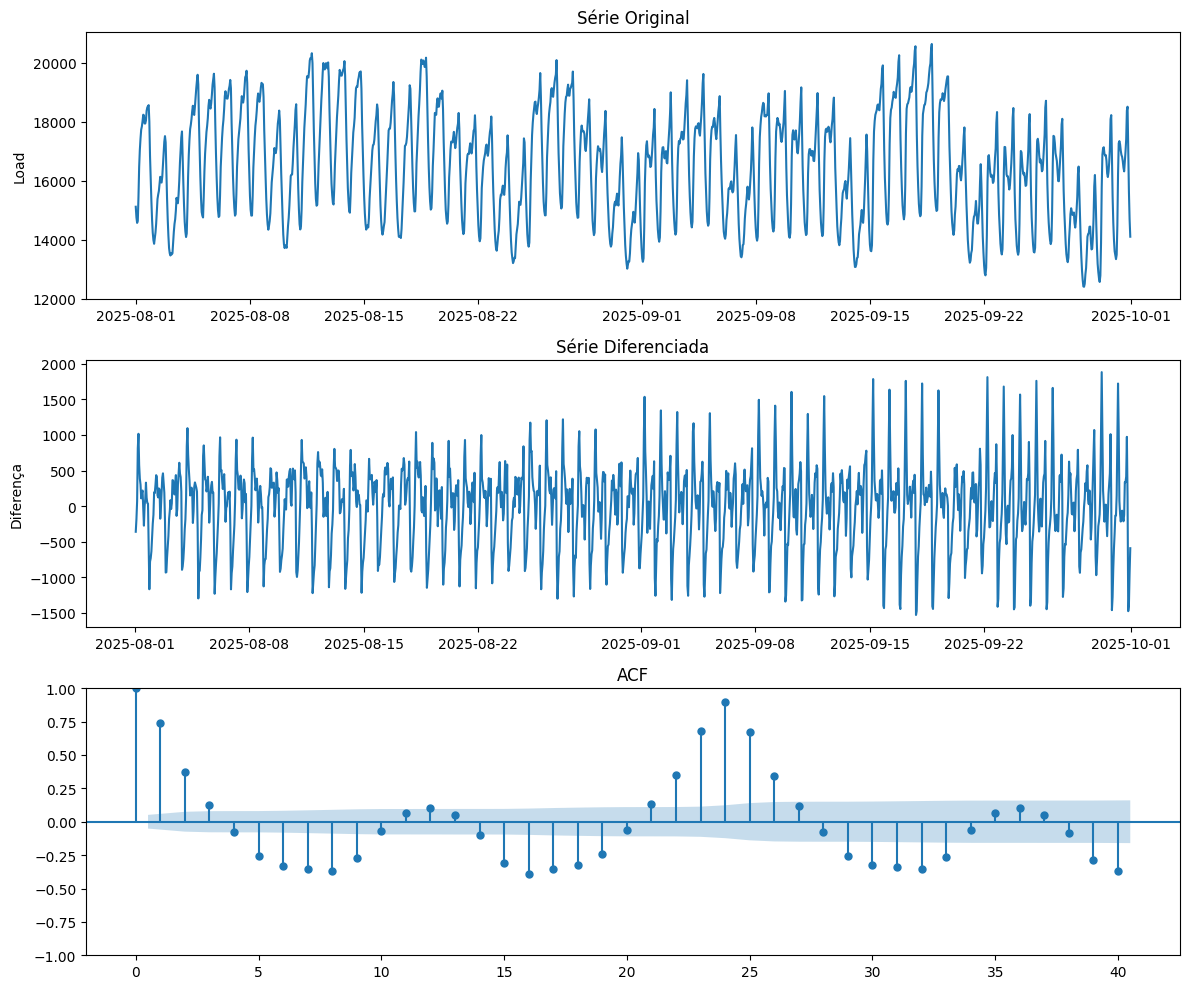

<Figure size 1000x500 with 0 Axes>

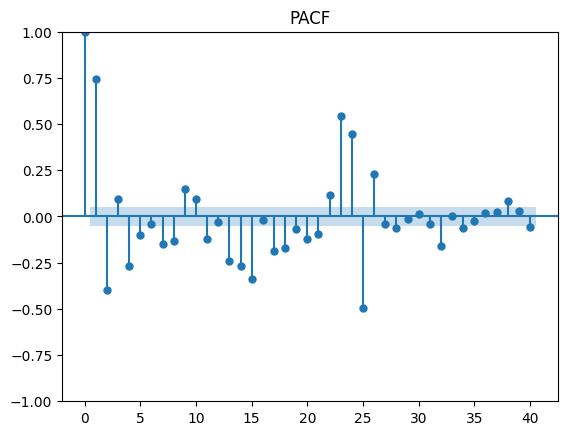

In [16]:
# Diferenciação para tornar a série estacionária
df_pt_diff = test.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(12,10))

# Série original (diária)
axes[0].plot(test)
axes[0].set_title("Série Original")
axes[0].set_ylabel("Load")

# Série diferenciada
axes[1].plot(df_pt_diff)
axes[1].set_title("Série Diferenciada")
axes[1].set_ylabel("Diferença")

# ACF
plot_acf(df_pt_diff, lags=40, ax=axes[2])
axes[2].set_title("ACF")

plt.tight_layout()
plt.show()

# =========================
# PACF separado (melhor leitura)
# =========================

plt.figure(figsize=(10,5))
plot_pacf(df_pt_diff, lags=40, method='ywm')
plt.title("PACF")
plt.show()

In [10]:
#Modelo Arima
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                24841
Model:                 ARIMA(2, 1, 2)   Log Likelihood             -184429.492
Date:                Sun, 26 Apr 2026   AIC                         368868.983
Time:                        19:50:40   BIC                         368909.584
Sample:                    09-30-2022   HQIC                        368882.129
                         - 07-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6064      0.004    434.741      0.000       1.599       1.614
ar.L2         -0.7408      0.003   -220.047      0.000      -0.747      -0.734
ma.L1         -0.5841      0.003   -212.549      0.0

In [11]:
#Forecast
forecast = model_fit.forecast(steps=len(test))

# Align forecast index with test
forecast = pd.Series(forecast.values, index=test.index)

# Avaliação
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test["Value"] - forecast) / test["Value"])) * 100

print("\n--- ARIMA Results ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


--- ARIMA Results ---
MAE:  1567.16
RMSE: 1886.65
MAPE: 10.00%


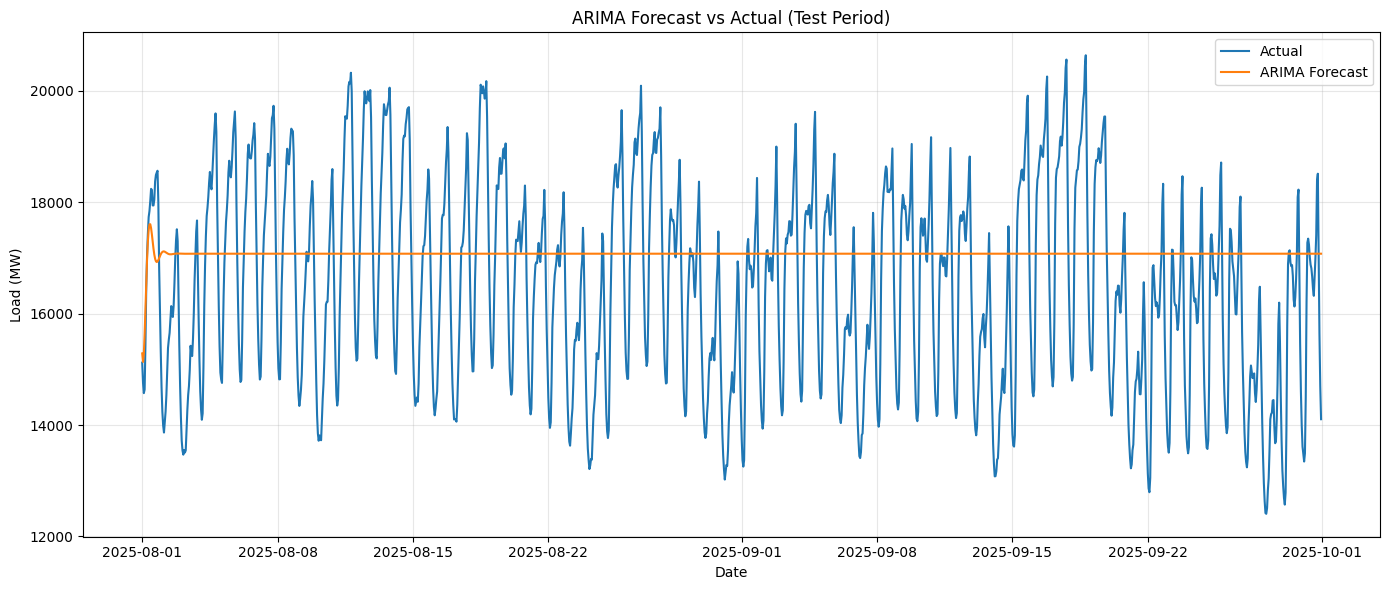

In [12]:
# =============================
# 7. Plot results
# =============================
plt.figure(figsize=(14,6))

plt.plot(test.index, test["Value"], label="Actual")
plt.plot(test.index, forecast, label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual (Test Period)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/arima_forecast.png", dpi=300)
plt.show()


In [13]:
# =============================
# 8. 24-hour forecast example
# =============================
forecast_24h = model_fit.forecast(steps=24)

# Align with first 24h of test
actual_24h = test["Value"].iloc[:24]
forecast_24h = pd.Series(forecast_24h.values, index=actual_24h.index)

df_eval_24h = pd.DataFrame({
    "actual": actual_24h,
    "forecast": forecast_24h
}).dropna()

mae_24 = mean_absolute_error(df_eval_24h["actual"], df_eval_24h["forecast"])
rmse_24 = np.sqrt(mean_squared_error(df_eval_24h["actual"], df_eval_24h["forecast"]))
mape_24 = np.mean(np.abs((df_eval_24h["actual"] - df_eval_24h["forecast"]) / df_eval_24h["actual"])) * 100

print("\n--- 24h Forecast ---")
print(f"MAE:  {mae_24:.2f}")
print(f"RMSE: {rmse_24:.2f}")
print(f"MAPE: {mape_24:.2f}%")


--- 24h Forecast ---
MAE:  753.46
RMSE: 917.56
MAPE: 4.39%


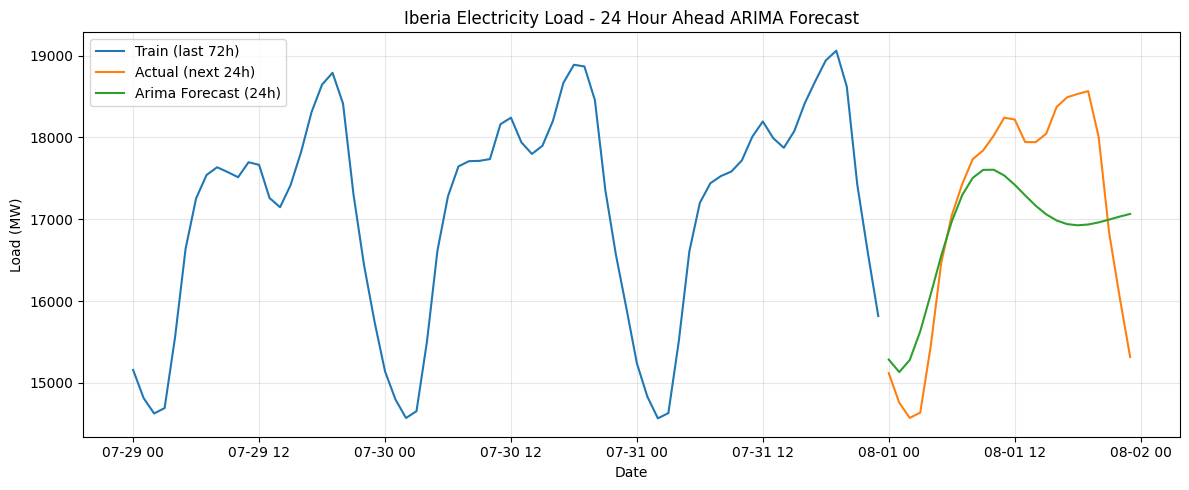

In [14]:
# -----------------------------
# 9. Plot 24h forecast
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    train.index[-72:],
    train["Value"].iloc[-72:],
    label="Train (last 72h)"
)

plt.plot(
    actual_24h.index,
    actual_24h,
    label="Actual (next 24h)"
)

plt.plot(
    actual_24h.index,
    forecast_24h,
    label="Arima Forecast (24h)"
)

plt.title("Iberia Electricity Load - 24 Hour Ahead ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/arima_forecast_24h.png", dpi=300)
plt.show()